#### Example

- How you get the dataset?
- Link/Script to donwload data.

In [2]:
import requests
import pandas as pd

# Fetch Cambodia CPI/Inflation from World Bank API
# Indicator: FP.CPI.TOTL.ZG = Inflation, consumer prices (annual %)
url = "https://api.worldbank.org/v2/country/KHM/indicator/FP.CPI.TOTL.ZG"
params = {"format": "json", "per_page": 100, "mrv": 40}

response = requests.get(url, params=params)
data = response.json()[1]

df = pd.DataFrame([{
    "year": int(entry["date"]),
    "inflation": entry["value"]
} for entry in data if entry["value"] is not None])

df = df.sort_values("year").reset_index(drop=True)
print(df)

    year  inflation
0   1995  -0.798944
1   1996   7.150861
2   1997   7.960214
3   1998  14.806504
4   1999   4.008207
5   2000  -0.791993
6   2001  -0.600648
7   2002   0.211467
8   2003   0.941746
9   2004   4.319337
10  2005   6.615259
11  2006   5.810686
12  2007   8.708828
13  2008  24.096852
14  2009  -1.241718
15  2010   3.996395
16  2011   5.478447
17  2012   2.934316
18  2013   2.941625
19  2014   3.855689
20  2015   1.223932
21  2016   3.019140
22  2017   2.912636
23  2018   2.459085
24  2019   1.942575
25  2020   2.940295
26  2021   2.920735
27  2022   5.343703
28  2023   2.127468
29  2024   0.808042


In [4]:
indicators = {
    "gdp_growth":     "NY.GDP.MKTP.KD.ZG",  # GDP growth %
    "money_supply":   "FM.LBL.BMNY.GD.ZS",  # Broad money (% of GDP)
    "trade_openness": "NE.TRD.GNFS.ZS",      # Trade % of GDP
    "exchange_rate":  "PA.NUS.FCRF",          # Official exchange rate
    "unemployment":   "SL.UEM.TOTL.ZS",       # Unemployment %
    "food_inflation": "FP.CPI.TOTL",          # CPI index
}

dfs = []
for name, indicator in indicators.items():
    url = f"https://api.worldbank.org/v2/country/KHM/indicator/{indicator}"
    r = requests.get(url, params={"format": "json", "per_page": 100}).json()
    if r and len(r) > 1:
        temp = pd.DataFrame([{
            "year": int(e["date"]),
            name: e["value"]
        } for e in r[1] if e["value"] is not None])
        dfs.append(temp)

# Merge all into one DataFrame
from functools import reduce
df_all = reduce(lambda l, r: pd.merge(l, r, on="year", how="outer"), [df] + dfs)
df_all = df_all.sort_values("year").dropna().reset_index(drop=True)
print(df_all.shape)
df_all.head()

(30, 8)


,year,inflation,gdp_growth,money_supply,trade_openness,exchange_rate,unemployment,food_inflation
0,1995,-0.798944,9.903469,7.696568,77.766728,2450.833333,0.973,44.509927
1,1996,7.150861,5.897506,9.906823,69.161567,2624.083333,0.963,47.692770
2,1997,7.960214,4.006621,10.476457,78.934644,2946.250000,0.638,51.489217
3,1998,14.806504,4.681632,10.495167,75.619473,3744.416667,0.712,59.112970
4,1999,4.008207,12.705381,10.784204,94.176888,3807.833333,0.727,61.482340


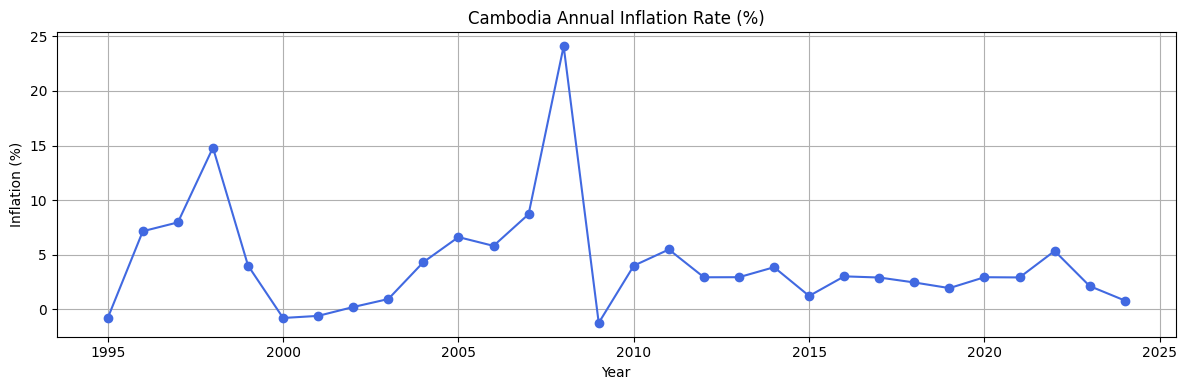

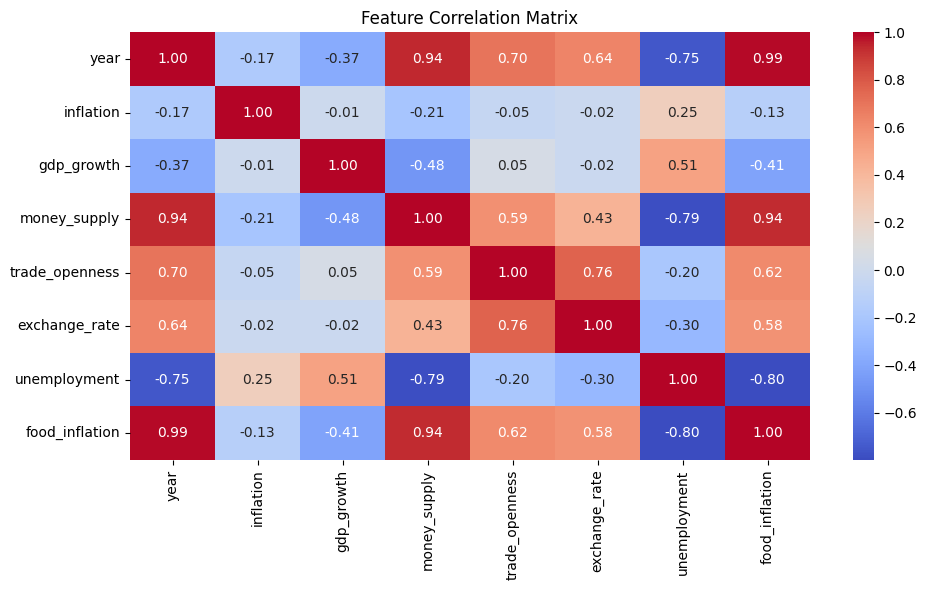

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot inflation over time
plt.figure(figsize=(12, 4))
plt.plot(df_all["year"], df_all["inflation"], marker="o", color="royalblue")
plt.title("Cambodia Annual Inflation Rate (%)")
plt.xlabel("Year"); plt.ylabel("Inflation (%)")
plt.grid(True); plt.tight_layout(); plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df_all.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.tight_layout(); plt.show()

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Features and target
X = df_all.drop(columns=["year", "inflation"])
y = df_all["inflation"]

# Train/test split (time-based — don't shuffle!)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Train multiple models
models = {
    "Linear Regression":    LinearRegression(),
    "Ridge Regression":     Ridge(alpha=1.0),
    "Random Forest":        RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting":    GradientBoostingRegressor(n_estimators=100, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train_s, y_train)
    preds = model.predict(X_test_s)
    results[name] = {
        "MAE":  round(mean_absolute_error(y_test, preds), 3),
        "RMSE": round(np.sqrt(mean_squared_error(y_test, preds)), 3),
        "R²":   round(r2_score(y_test, preds), 3),
    }

print(pd.DataFrame(results).T.sort_values("RMSE"))

                      MAE    RMSE      R²
Ridge Regression    3.320   3.635  -5.851
Random Forest       6.190   7.337 -26.903
Linear Regression   8.368   8.587 -37.224
Gradient Boosting  10.329  12.527 -80.352


Importing plotly failed. Interactive plots will not work.
00:58:51 - cmdstanpy - INFO - Chain [1] start processing
00:58:51 - cmdstanpy - INFO - Chain [1] done processing


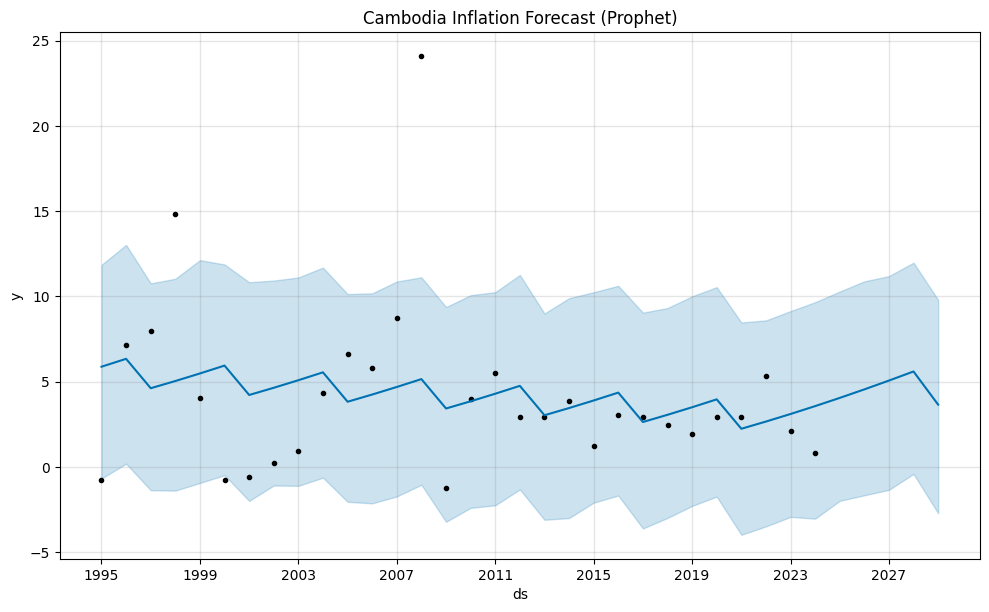

In [7]:
from prophet import Prophet

df_prophet = df_all[["year", "inflation"]].rename(columns={"year": "ds", "inflation": "y"})
df_prophet["ds"] = pd.to_datetime(df_prophet["ds"], format="%Y")

m = Prophet(yearly_seasonality=True)
m.fit(df_prophet)

future = m.make_future_dataframe(periods=5, freq="YE")
forecast = m.predict(future)
m.plot(forecast)
plt.title("Cambodia Inflation Forecast (Prophet)")
plt.show()

In [12]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, None],
    "min_samples_split": [2, 5],
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring="neg_mean_absolute_error"
)

grid.fit(X_train_s, y_train)

print("Best params:", grid.best_params_)
print("Best MAE:", -grid.best_score_)

Best params: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 50}
Best MAE: 5.847573759219579
